# Training a Custom Keyword Spotting Model — Modern TensorFlow / Keras Version

This notebook is a modernized replacement for the older TF1-era custom keyword spotting notebook.  
It avoids `tensorflow.compat.v1`, the deprecated `tensorflow/examples/speech_commands/train.py` workflow, frozen graphs, and TensorFlow I/O.

The new pipeline is:

1. Prepare the Speech Commands dataset plus optional uploaded custom recordings.
2. Build a `tf.data` input pipeline.
3. Convert each 1-second waveform to a 49 × 40 log-mel feature image using `tf.signal`.
4. Train a small Keras CNN.
5. Convert the model to float and fully quantized TensorFlow Lite.
6. Export a C array suitable for TensorFlow Lite for Microcontrollers.

**Important deployment caveat:** the model trained here expects **log-mel features** of shape `(49, 40, 1)`, not raw audio.  
On the microcontroller side, your feature-extraction code must produce the same feature layout/range. This is cleaner than the old TF1 training stack, but it is not a bit-for-bit clone of the old `speech_commands` `"micro"` frontend.

## Setup

This notebook is written for modern TensorFlow 2.x with Keras 3-style APIs.

As of the 2026 TensorFlow package line, the public stable package may not be named `tensorflow==2.29`. The code below intentionally uses stable TensorFlow 2.x APIs instead of pinning a fragile exact version.

In [31]:
# For a fresh Colab runtime, uncomment the next line, run it once, and restart the runtime.
# %pip install -q --upgrade tensorflow tensorboard

import os
import re
import math
import glob
import wave
import shutil
import random
import pathlib
import subprocess

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__ if hasattr(keras, "__version__") else "tf.keras")
assert int(tf.__version__.split(".")[0]) >= 2, "This notebook requires TensorFlow 2.x"

TensorFlow: 2.21.0
Keras: 3.14.1


In [32]:
# Colab-only import. If you run locally, this cell still works; upload/download helpers are simply unavailable.
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    files = None

print("Running in Colab:", IN_COLAB)

Running in Colab: False


## Download the base Speech Commands dataset

The base dataset provides the target words, unknown words, and background material that make custom keyword spotting much more robust than training only on a handful of custom recordings.

In [33]:
#DATASET_DIR = pathlib.Path("dataset")
#ARCHIVE = pathlib.Path("speech_commands_v0.02.tar.gz")

#if not DATASET_DIR.exists():
#    !wget -q https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz
#    DATASET_DIR.mkdir(exist_ok=True)
#    !tar -xf speech_commands_v0.02.tar.gz -C dataset
#    ARCHIVE.unlink(missing_ok=True)

#print("Dataset directory:", DATASET_DIR.resolve())
#print("Example folders:", sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])[:12])

import pathlib
import urllib.request
import tarfile

DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz"

DATASET_DIR = pathlib.Path("../../data/speech_commands")
ARCHIVE = pathlib.Path("speech_commands_v0.02.tar.gz")

EXPECTED_FOLDERS = [
    "yes", "no", "up", "down", "left", "right",
    "on", "off", "stop", "go", "_background_noise_"
]

def dataset_is_ready(dataset_dir: pathlib.Path) -> bool:
    return (
        dataset_dir.exists()
        and all((dataset_dir / folder).exists() for folder in EXPECTED_FOLDERS)
    )

if not dataset_is_ready(DATASET_DIR):
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    if not ARCHIVE.exists():
        print("Downloading Speech Commands dataset...")
        urllib.request.urlretrieve(DATASET_URL, ARCHIVE)
        print("Download complete.")

    print("Extracting dataset...")
    with tarfile.open(ARCHIVE, "r:gz") as tar:
        tar.extractall(DATASET_DIR)

    print("Extraction complete.")

    ARCHIVE.unlink(missing_ok=True)
else:
    print("Dataset already exists. Skipping download.")

print("Dataset directory:", DATASET_DIR.resolve())
print(
    "Example folders:",
    sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])[:12]
)

Dataset already exists. Skipping download.
Dataset directory: E:\workspace\tinyml\data\speech_commands
Example folders: ['_background_noise_', 'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four']


## Optional: upload custom `.ogg` recordings

The older notebook used Pete Warden's compiled `extract_loudest_section` utility.  
This version uses a small Python replacement:

1. Convert uploaded `.ogg` files to mono 16 kHz WAV with `ffmpeg`.
2. Extract the loudest one-second window.
3. Place the result in `dataset/<word>/<instance>.wav`.

Expected filename pattern:

```text
word_instance.ogg
```

Examples:

```text
start_001.ogg
stop_001.ogg
yes_linh_01.ogg
```

In [34]:
def ensure_ffmpeg():
    """Install/check ffmpeg in Colab-like Linux environments."""
    if shutil.which("ffmpeg") is None:
        if IN_COLAB:
            !apt-get -qq update
            !apt-get -qq install -y ffmpeg
        else:
            raise RuntimeError("ffmpeg is required. Install ffmpeg or skip the custom upload step.")

def write_wav_mono_16k(path, audio, sample_rate=16000):
    audio = np.asarray(audio, dtype=np.float32)
    audio = np.clip(audio, -1.0, 1.0)
    pcm16 = (audio * 32767.0).astype("<i2")
    with wave.open(str(path), "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(sample_rate)
        f.writeframes(pcm16.tobytes())

def decode_wav_numpy(path):
    audio_binary = tf.io.read_file(str(path))
    audio, sample_rate = tf.audio.decode_wav(audio_binary, desired_channels=1)
    return tf.squeeze(audio, axis=-1).numpy(), int(sample_rate.numpy())

def extract_loudest_one_second(input_wav, output_wav, sample_rate=16000):
    audio, sr = decode_wav_numpy(input_wav)
    if sr != sample_rate:
        raise ValueError(f"Expected {sample_rate} Hz after ffmpeg conversion, got {sr} Hz")

    target_len = sample_rate
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
        write_wav_mono_16k(output_wav, audio, sample_rate)
        return

    power = audio.astype(np.float64) ** 2
    cumsum = np.concatenate([[0.0], np.cumsum(power)])
    window_energy = cumsum[target_len:] - cumsum[:-target_len]
    start = int(np.argmax(window_energy))
    clip = audio[start:start + target_len]
    write_wav_mono_16k(output_wav, clip, sample_rate)

def import_uploaded_ogg_files():
    if not IN_COLAB:
        print("Not running in Colab. Put .ogg files in the current directory and rerun this cell.")
        return

    ensure_ffmpeg()
    uploaded = files.upload()
    upload_dir = pathlib.Path("uploaded_ogg")
    converted_dir = pathlib.Path("converted_wav")
    upload_dir.mkdir(exist_ok=True)
    converted_dir.mkdir(exist_ok=True)

    for filename in uploaded.keys():
        src = pathlib.Path(filename)
        dst = upload_dir / src.name
        if src.exists():
            shutil.move(str(src), str(dst))

    for ogg_path in sorted(upload_dir.glob("*.ogg")):
        stem = ogg_path.stem
        # Accept word_instance or word_extra_instance; first token is the word.
        parts = stem.split("_")
        if len(parts) < 2:
            raise ValueError(f"Filename must look like word_instance.ogg: {ogg_path.name}")

        word = parts[0].lower()
        instance = "_".join(parts[1:]).lower()
        word_dir = DATASET_DIR / word
        word_dir.mkdir(exist_ok=True)

        temp_wav = converted_dir / f"{stem}.wav"
        output_wav = word_dir / f"{instance}.wav"

        subprocess.run([
            "ffmpeg", "-y", "-i", str(ogg_path),
            "-ac", "1", "-ar", "16000", str(temp_wav)
        ], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        extract_loudest_one_second(temp_wav, output_wav)
        print(f"Stored {output_wav}")

# Uncomment this line when you want to upload custom recordings.
# import_uploaded_ogg_files()

## Configure the model

`WANTED_WORDS` is the comma-separated list of keywords to recognize.

The output label order is intentionally:

```text
silence, unknown, <wanted words...>
```

That matches the usual TinyML keyword-spotting convention.

In [35]:
WANTED_WORDS = "yes,no"

wanted_words = [w.strip().lower() for w in WANTED_WORDS.split(",") if w.strip()]
label_names = ["silence", "unknown"] + wanted_words
label_to_index = {name: i for i, name in enumerate(label_names)}

print("Wanted words:", wanted_words)
print("Labels:", label_names)

Wanted words: ['yes', 'no']
Labels: ['silence', 'unknown', 'yes', 'no']


In [36]:
# Audio and feature-extraction settings
SAMPLE_RATE = 16000
CLIP_DURATION_MS = 1000
SAMPLES = SAMPLE_RATE * CLIP_DURATION_MS // 1000

WINDOW_SIZE_MS = 30.0
WINDOW_STRIDE_MS = 20.0
FRAME_LENGTH = int(SAMPLE_RATE * WINDOW_SIZE_MS / 1000)
FRAME_STEP = int(SAMPLE_RATE * WINDOW_STRIDE_MS / 1000)
FFT_LENGTH = 512
FEATURE_BIN_COUNT = 40

# 49 frames x 40 mel bins for a 1-second clip with 30 ms window and 20 ms stride.
EXPECTED_FRAMES = 1 + (SAMPLES - FRAME_LENGTH) // FRAME_STEP
FEATURE_SHAPE = (EXPECTED_FRAMES, FEATURE_BIN_COUNT, 1)

# Training settings
VALIDATION_PERCENTAGE = 10
TESTING_PERCENTAGE = 10
BATCH_SIZE = 64
EPOCHS = 20
RANDOM_SEED = 123

# Use None to use all examples from the smallest wanted class.
# Set a smaller value, e.g., 800, for faster classroom demonstrations.
MAX_EXAMPLES_PER_CLASS = None

MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

KERAS_MODEL = MODELS_DIR / "KWS_custom.keras"
SAVED_MODEL = MODELS_DIR / "KWS_custom_saved_model"
FLOAT_MODEL_TFLITE = MODELS_DIR / "KWS_custom_float.tflite"
MODEL_TFLITE = MODELS_DIR / "KWS_custom_int8.tflite"
MODEL_TFLITE_MICRO = MODELS_DIR / "KWS_custom.cc"
LABELS_TXT = MODELS_DIR / "labels.txt"

print("Feature shape:", FEATURE_SHAPE)

Feature shape: (49, 40, 1)


## Build balanced file lists

For classroom use, a balanced subset is more predictable than throwing the entire Speech Commands dataset into the model and hoping the class distribution behaves itself. Hope is not a data pipeline.

In [37]:
def list_wavs_for_word(word):
    word_dir = DATASET_DIR / word
    if not word_dir.exists():
        return []
    return sorted(str(p) for p in word_dir.glob("*.wav"))

def split_items(items, validation_pct=10, testing_pct=10, seed=123):
    rng = random.Random(seed)
    items = list(items)
    rng.shuffle(items)

    n = len(items)
    n_test = int(n * testing_pct / 100)
    n_val = int(n * validation_pct / 100)

    test = items[:n_test]
    val = items[n_test:n_test + n_val]
    train = items[n_test + n_val:]
    return train, val, test

def build_labeled_items():
    rng = random.Random(RANDOM_SEED)

    wanted_paths = {word: list_wavs_for_word(word) for word in wanted_words}
    missing = [word for word, paths in wanted_paths.items() if len(paths) == 0]
    if missing:
        raise ValueError(
            f"No WAV files found for wanted word(s): {missing}. "
            f"Upload custom files or choose words present in {DATASET_DIR}."
        )

    smallest_class = min(len(paths) for paths in wanted_paths.values())
    target_per_class = smallest_class
    if MAX_EXAMPLES_PER_CLASS is not None:
        target_per_class = min(target_per_class, int(MAX_EXAMPLES_PER_CLASS))

    all_word_dirs = [
        p.name for p in DATASET_DIR.iterdir()
        if p.is_dir() and p.name != "_background_noise_"
    ]
    unknown_words = sorted(set(all_word_dirs) - set(wanted_words))
    unknown_candidates = []
    for word in unknown_words:
        unknown_candidates.extend(list_wavs_for_word(word))
    rng.shuffle(unknown_candidates)

    if len(unknown_candidates) < target_per_class:
        raise ValueError("Not enough unknown-word examples to build the dataset.")

    labeled = []

    # Silence examples use a sentinel path; the loader turns this into a zero waveform.
    labeled.extend([("__silence__", label_to_index["silence"])] * target_per_class)

    # Unknown examples come from words not in WANTED_WORDS.
    labeled.extend([(p, label_to_index["unknown"]) for p in unknown_candidates[:target_per_class]])

    # Wanted examples.
    for word, paths in wanted_paths.items():
        chosen = paths[:]
        rng.shuffle(chosen)
        chosen = chosen[:target_per_class]
        labeled.extend([(p, label_to_index[word]) for p in chosen])

    train, val, test = split_items(
        labeled,
        validation_pct=VALIDATION_PERCENTAGE,
        testing_pct=TESTING_PERCENTAGE,
        seed=RANDOM_SEED,
    )

    print(f"Target examples per class: {target_per_class}")
    print(f"Train/val/test sizes: {len(train)}, {len(val)}, {len(test)}")
    return train, val, test

train_items, val_items, test_items = build_labeled_items()

Target examples per class: 3941
Train/val/test sizes: 12612, 1576, 1576


## Audio loading and feature extraction

The model does not learn from raw waveform samples directly. Each audio clip is converted to a compact log-mel spectrogram:

- 1 second audio at 16 kHz
- 30 ms analysis window
- 20 ms stride
- 40 mel bins
- output shape: 49 × 40 × 1

In [38]:
def load_audio(path):
    path = tf.convert_to_tensor(path, dtype=tf.string)
    is_silence = tf.equal(path, "__silence__")

    def silence_audio():
        return tf.zeros([SAMPLES], dtype=tf.float32)

    def file_audio():
        audio_binary = tf.io.read_file(path)
        audio, sample_rate = tf.audio.decode_wav(audio_binary, desired_channels=1)
        audio = tf.squeeze(audio, axis=-1)

        # The base Speech Commands dataset is already 16 kHz. Uploaded files are converted to 16 kHz.
        audio = audio[:SAMPLES]
        padding = tf.maximum(SAMPLES - tf.shape(audio)[0], 0)
        audio = tf.pad(audio, [[0, padding]])
        audio.set_shape([SAMPLES])
        return audio

    return tf.cond(is_silence, silence_audio, file_audio)

def time_shift(audio, max_shift_ms=100.0):
    max_shift = int(SAMPLE_RATE * max_shift_ms / 1000)
    shift = tf.random.uniform([], -max_shift, max_shift + 1, dtype=tf.int32)

    def shift_right():
        return tf.concat([tf.zeros([shift], dtype=audio.dtype), audio[:-shift]], axis=0)

    def shift_left():
        left = -shift
        return tf.concat([audio[left:], tf.zeros([left], dtype=audio.dtype)], axis=0)

    return tf.case(
        [(shift > 0, shift_right), (shift < 0, shift_left)],
        default=lambda: audio,
        exclusive=True,
    )

def waveform_to_log_mel(audio):
    stft = tf.signal.stft(
        audio,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FFT_LENGTH,
        window_fn=tf.signal.hann_window,
        pad_end=False,
    )
    spectrogram = tf.abs(stft)

    mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=FEATURE_BIN_COUNT,
        num_spectrogram_bins=FFT_LENGTH // 2 + 1,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=20.0,
        upper_edge_hertz=4000.0,
    )

    mel = tf.matmul(tf.square(spectrogram), mel_weight_matrix)
    log_mel = tf.math.log(mel + 1e-6)
    log_mel.set_shape([EXPECTED_FRAMES, FEATURE_BIN_COUNT])
    return log_mel

def make_example(path, label, training=False):
    audio = load_audio(path)

    if training:
        audio = time_shift(audio)
        audio = audio + tf.random.normal(tf.shape(audio), stddev=0.004)
        audio = tf.clip_by_value(audio, -1.0, 1.0)

    features = waveform_to_log_mel(audio)
    features = tf.expand_dims(features, axis=-1)
    return features, label

In [39]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(items, training=False):
    paths = [p for p, _ in items]
    labels = [label for _, label in items]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(items), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, y: make_example(p, y, training=training),
        num_parallel_calls=AUTOTUNE,
    )
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_items, training=True)
val_ds = make_dataset(val_items, training=False)
test_ds = make_dataset(test_items, training=False)

for x_batch, y_batch in train_ds.take(1):
    print("Feature batch:", x_batch.shape, x_batch.dtype)
    print("Label batch:", y_batch.shape, y_batch.dtype)

Feature batch: (64, 49, 40, 1) <dtype: 'float32'>
Label batch: (64,) <dtype: 'int32'>


## Visual sanity check

This is worth keeping in the student-facing notebook. Most bad audio pipelines fail visibly before they fail mathematically.

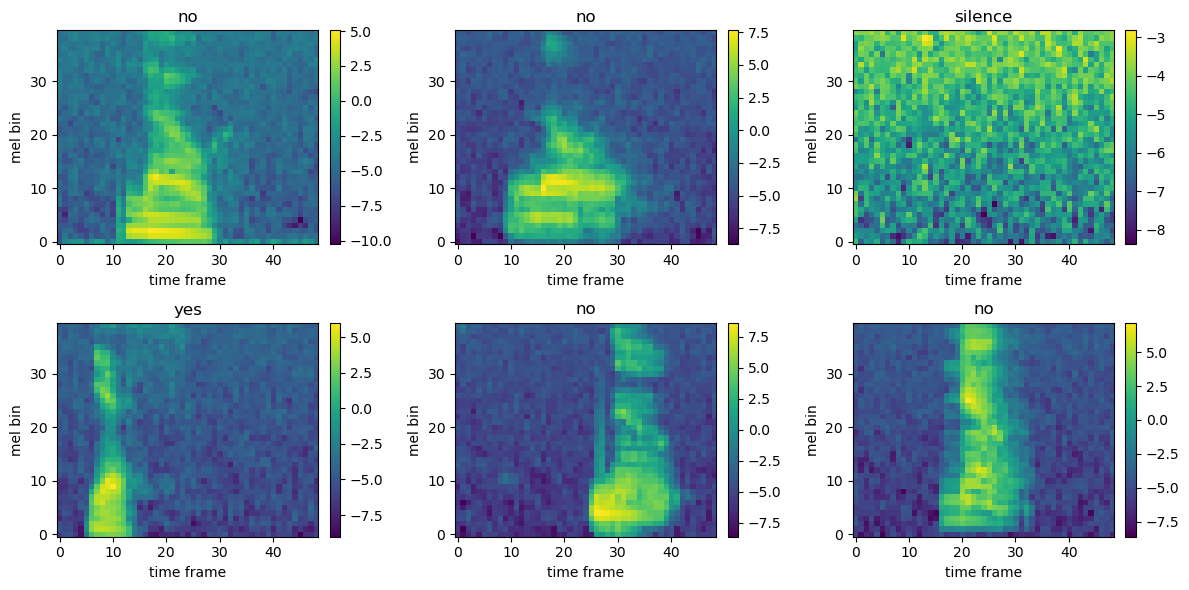

In [40]:
import matplotlib.pyplot as plt

def show_examples(dataset, count=6):
    plt.figure(figsize=(12, 6))
    shown = 0
    for features, labels in dataset.unbatch().take(count):
        shown += 1
        plt.subplot(2, math.ceil(count / 2), shown)
        plt.imshow(tf.squeeze(features, axis=-1).numpy().T, aspect="auto", origin="lower")
        plt.title(label_names[int(labels.numpy())])
        plt.xlabel("time frame")
        plt.ylabel("mel bin")
        plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

show_examples(train_ds, count=6)

# Train the model

This is a small CNN roughly in the spirit of the old `tiny_conv` model, but implemented directly in Keras.

In [41]:
def build_kws_model(input_shape=FEATURE_SHAPE, num_labels=len(label_names)):
    inputs = keras.Input(shape=input_shape, name="log_mel_features")
    x = layers.Conv2D(8, kernel_size=(10, 4), strides=(2, 2), padding="same", activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(num_labels, name="logits")(x)
    return keras.Model(inputs, outputs, name="tiny_kws_logmel")

model = build_kws_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()

Model: "tiny_kws_logmel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_mel_features (InputLayer)   │ (None, 49, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 20, 8)      │           328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 4)              │        16,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,332 (63.80 KB)

 Trainable params: 16,332 (63.80 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
LOGS_DIR = pathlib.Path("logs")
LOGS_DIR.mkdir(exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
    )
]

# TensorBoard is optional. If tensorboard is not installed, training still works.
try:
    import tensorboard  # noqa: F401
    callbacks.append(keras.callbacks.TensorBoard(log_dir=str(LOGS_DIR)))
except Exception:
    print("TensorBoard package not available; skipping TensorBoard callback.")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

TensorBoard package not available; skipping TensorBoard callback.
Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6873 - loss: 0.7473 - val_accuracy: 0.7773 - val_loss: 0.4823
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8165 - loss: 0.4486 - val_accuracy: 0.7805 - val_loss: 0.5201
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8478 - loss: 0.3872 - val_accuracy: 0.8433 - val_loss: 0.3900
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8563 - loss: 0.3620 - val_accuracy: 0.8515 - val_loss: 0.3855
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8729 - loss: 0.3321 - val_accuracy: 0.8566 - val_loss: 0.3823
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8736 - loss: 0.3312 - val_accuracy: 0.8668 - val_loss: 0.3454
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8758 - loss: 0.3211 - val_accuracy: 0.8902 - val_loss: 0.3188
Epoch 8/20
198/198 ━━━━━━━━━━━━

In [43]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Keras test accuracy: {test_accuracy * 100:.2f}%")

Keras test accuracy: 88.77%


## Optional TensorBoard

Run this only if the `tensorboard` package is installed in your environment.

In [44]:
# %load_ext tensorboard
# %tensorboard --logdir logs

# Save the Keras model and export a SavedModel

With Keras 3-style APIs, use `.keras` for the native Keras model and `model.export(...)` for TensorFlow SavedModel export.  
This replaces the old frozen-graph workflow.

In [45]:
model.save(KERAS_MODEL)

if SAVED_MODEL.exists():
    shutil.rmtree(SAVED_MODEL)

# Keras 3 preferred SavedModel export path.
if hasattr(model, "export"):
    model.export(SAVED_MODEL)
else:
    tf.saved_model.save(model, SAVED_MODEL)

LABELS_TXT.write_text("\n".join(label_names), encoding="utf-8")

print("Saved Keras model:", KERAS_MODEL)
print("Exported SavedModel:", SAVED_MODEL)
print("Saved labels:", LABELS_TXT)

INFO:tensorflow:Assets written to: models\KWS_custom_saved_model\assets


INFO:tensorflow:Assets written to: models\KWS_custom_saved_model\assets


Saved artifact at 'models\KWS_custom_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='log_mel_features')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2624756034320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756033744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756024144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756025104: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved Keras model: models\KWS_custom.keras
Exported SavedModel: models\KWS_custom_saved_model
Saved labels: models\labels.txt


# Convert to TensorFlow Lite

The float model is useful for debugging.  
The int8 model is the one you usually deploy to a microcontroller.

In [46]:
float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
float_tflite_model = float_converter.convert()
FLOAT_MODEL_TFLITE.write_bytes(float_tflite_model)
print(f"Float model size: {FLOAT_MODEL_TFLITE.stat().st_size} bytes")

INFO:tensorflow:Assets written to: C:\Users\LINHBN~1\AppData\Local\Temp\tmplc1t9l78\assets


INFO:tensorflow:Assets written to: C:\Users\LINHBN~1\AppData\Local\Temp\tmplc1t9l78\assets


Saved artifact at 'C:\Users\LINHBN~1\AppData\Local\Temp\tmplc1t9l78'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='log_mel_features')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2624756034320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756033744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756024144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756025104: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float model size: 68188 bytes


In [47]:
REP_DATA_SIZE = 100

def representative_dataset_gen():
    count = 0
    for features, _ in train_ds.unbatch().take(REP_DATA_SIZE):
        yield [tf.cast(tf.expand_dims(features, axis=0), tf.float32)]
        count += 1

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen

# Force full integer quantization for MCU deployment.
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_tflite_model = converter.convert()
MODEL_TFLITE.write_bytes(int8_tflite_model)
print(f"Int8 quantized model size: {MODEL_TFLITE.stat().st_size} bytes")

INFO:tensorflow:Assets written to: C:\Users\LINHBN~1\AppData\Local\Temp\tmp_cj0cpn8\assets


INFO:tensorflow:Assets written to: C:\Users\LINHBN~1\AppData\Local\Temp\tmp_cj0cpn8\assets


Saved artifact at 'C:\Users\LINHBN~1\AppData\Local\Temp\tmp_cj0cpn8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 40, 1), dtype=tf.float32, name='log_mel_features')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2624756034320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756033744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756024144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2624756025104: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\Linh B Ngo\.conda\envs\tinyml\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Int8 quantized model size: 19752 bytes


# Test TensorFlow Lite accuracy

This evaluates both the float and quantized `.tflite` files using the TensorFlow Lite Python interpreter.

In [48]:
def run_tflite_inference_testset(tflite_model_path, model_type="Float"):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    correct = 0
    total = 0

    for features, labels in test_ds.unbatch().batch(1):
        input_data = features.numpy()

        if input_details["dtype"] in (np.int8, np.uint8):
            input_scale, input_zero_point = input_details["quantization"]
            if input_scale == 0:
                raise ValueError("Quantized input scale is zero.")
            input_data = np.round(input_data / input_scale + input_zero_point)
            input_data = np.clip(
                input_data,
                np.iinfo(input_details["dtype"]).min,
                np.iinfo(input_details["dtype"]).max,
            ).astype(input_details["dtype"])
        else:
            input_data = input_data.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], input_data)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])[0]
        prediction = int(np.argmax(output))
        correct += int(prediction == int(labels.numpy()[0]))
        total += 1

    print(f"{model_type} model accuracy: {(correct * 100) / total:.2f}% ({correct}/{total})")

run_tflite_inference_testset(FLOAT_MODEL_TFLITE, "Float")
run_tflite_inference_testset(MODEL_TFLITE, "Int8")

c:\Users\Linh B Ngo\.conda\envs\tinyml\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Float model accuracy: 88.77% (1399/1576)
Int8 model accuracy: 89.53% (1411/1576)


# Generate a TensorFlow Lite for Microcontrollers C array

This replaces the shell-based `xxd` step with a pure Python exporter, so it works more consistently across notebooks and operating systems.

In [52]:
def write_tflite_micro_cc(tflite_path, cc_path, array_name="g_model"):
    data = pathlib.Path(tflite_path).read_bytes()

    lines = []

    for i in range(0, len(data), 12):
        chunk = data[i:i + 12]
        hex_values = ", ".join(f"0x{byte:02x}" for byte in chunk)
        lines.append(f"  {hex_values},\n")

    pathlib.Path(cc_path).write_text("".join(lines), encoding="utf-8")

write_tflite_micro_cc(MODEL_TFLITE, MODEL_TFLITE_MICRO, array_name="g_model")

print("Wrote:", MODEL_TFLITE_MICRO)
print("C array size:", MODEL_TFLITE_MICRO.stat().st_size, "bytes")

write_tflite_micro_cc(MODEL_TFLITE, MODEL_TFLITE_MICRO, array_name="g_model")
print("Wrote:", MODEL_TFLITE_MICRO)
print("C array size:", MODEL_TFLITE_MICRO.stat().st_size, "bytes")

Wrote: models\KWS_custom.cc
C array size: 123450 bytes
Wrote: models\KWS_custom.cc
C array size: 123450 bytes


In [53]:
# Print the beginning of the generated C file.
print(MODEL_TFLITE_MICRO.read_text(encoding="utf-8")[:1200])

  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x90, 0x00, 0x00, 0x00, 0xe8, 0x00, 0x00, 0x00, 0x24, 0x42, 0x00, 0x00,
  0x34, 0x42, 0x00, 0x00, 0x70, 0x4c, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x42, 0xbd, 0xff, 0xff,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x8c, 0xff, 0xff, 0xff, 0x0d, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
  0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x4a, 0xbd, 0xff, 0xff, 0x04, 0x00, 0x00, 0x00,
  0x10, 0x00, 0x00, 0x00, 0x6c, 0x6f, 

## Download model artifacts

In Colab, uncomment the download commands.  
For local Jupyter, the files are in the `models/` directory.

In [51]:
if IN_COLAB:
    # Uncomment the artifacts you want to download.
    # files.download(str(MODEL_TFLITE_MICRO))
    # files.download(str(MODEL_TFLITE))
    # files.download(str(FLOAT_MODEL_TFLITE))
    # files.download(str(LABELS_TXT))
    pass

print("Artifacts:")
for path in [KERAS_MODEL, SAVED_MODEL, FLOAT_MODEL_TFLITE, MODEL_TFLITE, MODEL_TFLITE_MICRO, LABELS_TXT]:
    print(" -", path)

Artifacts:
 - models\KWS_custom.keras
 - models\KWS_custom_saved_model
 - models\KWS_custom_float.tflite
 - models\KWS_custom_int8.tflite
 - models\KWS_custom.cc
 - models\labels.txt
